# Fixed Income Analytics Demo

This notebook demonstrates pricing and risk analytics for straight bonds as covered in the **CFA Level II & III** curriculum. It includes:
- Bond pricing (clean/dirty)
- Yield curve construction
- Spread analysis (G, I, Z spreads)
- Duration and convexity
- Key rate duration (CFA Level III)
- Credit risk estimation

---

In [1]:
from bond_pricing import bond_price, accrued_interest, dirty_price
from yield_curve import bootstrap_spot_rates, forward_rate, plot_yield_curve
from spreads import g_spread, i_spread, z_spread
from duration_convexity import (
    macaulay_duration, modified_duration, effective_duration, convexity,
    key_rate_duration, calculate_all_key_rate_durations, bond_price_from_spot_curve
)
from credit_risk import credit_risk_analysis

import matplotlib.pyplot as plt
import numpy as np


## 1. Bond Pricing

In [2]:
# Bond parameters
face_value = 1000
coupon_rate = 0.05
ytm = 0.06
years = 5
freq = 2
periods = years * freq

# Clean price calculation
clean = bond_price(face_value, coupon_rate, periods, ytm, freq)
print(f"Clean Price: {clean:.2f}")

# Accrued interest (assume 90 days into 180-day period)
accrued = accrued_interest(face_value, coupon_rate, 90, 180, freq)
print(f"Accrued Interest: {accrued:.2f}")

# Dirty price
dirty = dirty_price(clean, accrued)
print(f"Dirty Price: {dirty:.2f}")


Clean Price: 957.35
Accrued Interest: 12.50
Dirty Price: 969.85


## 2. Yield Curve Construction

Bootstrapped Spot Rates:
Year 1: -179.8992%
Year 2: -136.3529%
Year 3: -106.3712%
Year 4: -86.3534%
Year 5: -72.2574%


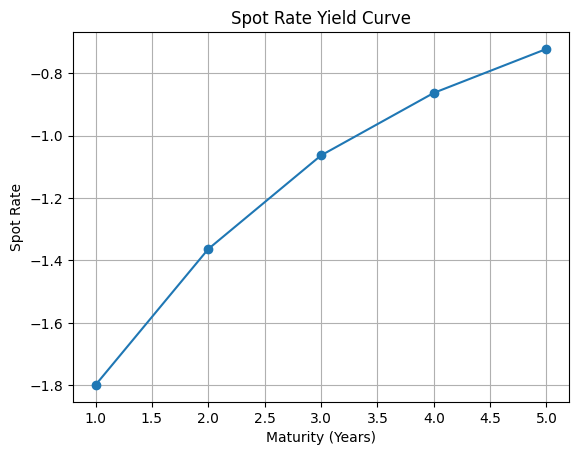

In [3]:
# Sample bond data (simulate a strip of increasing maturities)
bond_data = [
    {'price': 99.0, 'coupon_rate': 0.0, 'maturity': 1},
    {'price': 97.5, 'coupon_rate': 0.0, 'maturity': 2},
    {'price': 95.0, 'coupon_rate': 0.0, 'maturity': 3},
    {'price': 92.0, 'coupon_rate': 0.0, 'maturity': 4},
    {'price': 88.5, 'coupon_rate': 0.0, 'maturity': 5},
]

spot_rates = bootstrap_spot_rates(bond_data, freq)
print("Bootstrapped Spot Rates:")
for m, r in spot_rates.items():
    print(f"Year {m}: {r:.4%}")

# Plot
plot_yield_curve(spot_rates)


## 3. Credit Spreads

In [4]:
gov_ytm = 0.045
swap_ytm = 0.048
corp_ytm = ytm

print(f"G-spread: {g_spread(corp_ytm, gov_ytm):.2f} bps")
print(f"I-spread: {i_spread(corp_ytm, swap_ytm):.2f} bps")

z = z_spread(clean, face_value, coupon_rate, spot_rates, freq)
print(f"Z-spread: {z:.2f} bps")


G-spread: 150.00 bps
I-spread: 120.00 bps
Z-spread: 999.93 bps


## 4. Duration and Convexity

In [5]:
mac_dur = macaulay_duration(face_value, coupon_rate, ytm, periods, freq)
mod_dur = modified_duration(mac_dur, ytm, freq)
conv = convexity(face_value, coupon_rate, ytm, periods, freq)

# Effective duration using small shift in YTM
delta_y = 0.01
price_up = bond_price(face_value, coupon_rate, periods, ytm + delta_y, freq)
price_down = bond_price(face_value, coupon_rate, periods, ytm - delta_y, freq)
eff_dur = effective_duration(price_up, price_down, clean, delta_y)

print(f"Macaulay Duration: {mac_dur:.4f} years")
print(f"Modified Duration: {mod_dur:.4f}")
print(f"Effective Duration: {eff_dur:.4f}")
print(f"Convexity: {conv:.4f}")


Macaulay Duration: 4.4717 years
Modified Duration: 4.3414
Effective Duration: 4.3436
Convexity: 22.3047


## 5. Credit Risk Estimation

In [6]:
rating = 'BB'
lgd = 0.6  # 60% loss given default
ead = face_value

pd, el = credit_risk_analysis(rating, lgd, ead)
print(f"Rating: {rating}")
print(f"PD: {pd:.2%}")
print(f"Expected Loss: ${el:.2f}")


Rating: BB
PD: 1.00%
Expected Loss: $6.00


## 6. Key Rate Duration

Key rate duration measures the sensitivity of a bond's price to changes at **specific points** on the yield curve, holding all other rates constant. Unlike regular duration (which assumes parallel shifts), key rate duration captures non-parallel yield curve movements like steepening, flattening, and butterfly shifts.


In [7]:
# Create a realistic spot rate curve (similar to US Treasury curve)
spot_curve = {
    0.5: 0.0320,   # 6-month
    1: 0.0350,     # 1-year
    2: 0.0400,     # 2-year
    3: 0.0430,     # 3-year
    5: 0.0450,     # 5-year
    7: 0.0465,     # 7-year
    10: 0.0480,    # 10-year
}

print("Spot Rate Curve:")
for maturity, rate in sorted(spot_curve.items()):
    print(f"  {maturity:>4.1f} year: {rate*100:>5.2f}%")


Spot Rate Curve:
   0.5 year:  3.20%
   1.0 year:  3.50%
   2.0 year:  4.00%
   3.0 year:  4.30%
   5.0 year:  4.50%
   7.0 year:  4.65%
  10.0 year:  4.80%


In [8]:
# Calculate key rate durations for a 10-year bond
bond_face = 100
bond_coupon = 0.045  # 4.5% coupon
bond_maturity = 10

# Price the bond using the spot curve
bond_px = bond_price_from_spot_curve(bond_face, bond_coupon, bond_maturity, spot_curve)
print(f"10-Year Bond (4.5% coupon):")
print(f"  Price: ${bond_px:.4f}\n")

# Calculate all key rate durations
krds = calculate_all_key_rate_durations(bond_face, bond_coupon, bond_maturity, spot_curve)

print("Key Rate Durations:")
print(f"{'Maturity':<12} {'KRD':<12} {'% of Total':<12}")
print("-" * 40)

total_krd = sum(krds.values())
for mat, krd in sorted(krds.items()):
    pct = (krd / total_krd * 100) if total_krd > 0 else 0
    print(f"{mat:>5.1f} year    {krd:>8.4f}     {pct:>6.2f}%")

print(f"\nSum of KRDs: {total_krd:.4f}")
print(f"(Approximates effective duration)")

# Calculate single key rate duration for the 5-year point
krd_5y = key_rate_duration(bond_face, bond_coupon, bond_maturity, spot_curve, 
                           key_rate_maturity=5)
print(f"\n5-Year Key Rate Duration: {krd_5y:.4f}")
print(f"Interpretation: A 1bp increase in the 5-year rate decreases")
print(f"                bond price by approximately ${bond_px * krd_5y * 0.0001:.4f}")


10-Year Bond (4.5% coupon):
  Price: $98.0525

Key Rate Durations:
Maturity     KRD          % of Total  
----------------------------------------
  0.5 year      0.0111       0.16%
  1.0 year      0.0378       0.53%
  2.0 year      0.0829       1.16%
  5.0 year      0.3573       5.00%
 10.0 year      6.6639      93.16%

Sum of KRDs: 7.1530
(Approximates effective duration)

5-Year Key Rate Duration: 0.3573
Interpretation: A 1bp increase in the 5-year rate decreases
                bond price by approximately $0.0035


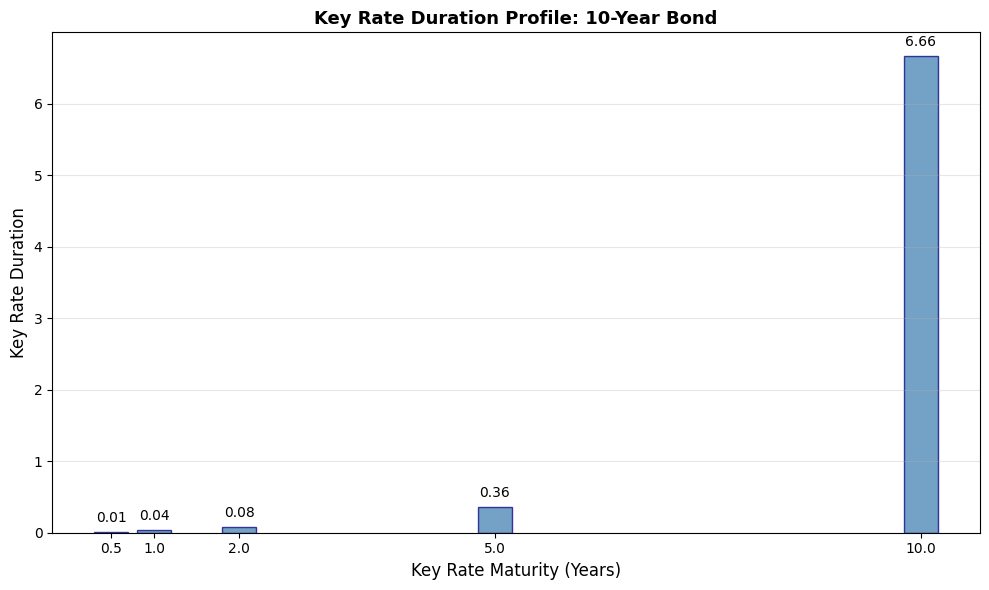

Key Insight: KRD is highest near the bond's maturity (10-year point)


In [9]:
# Visualize key rate duration profile
maturities = sorted(krds.keys())
krd_values = [krds[m] for m in maturities]

plt.figure(figsize=(10, 6))
plt.bar(maturities, krd_values, width=0.4, alpha=0.75, color='steelblue', edgecolor='navy')
plt.xlabel('Key Rate Maturity (Years)', fontsize=12)
plt.ylabel('Key Rate Duration', fontsize=12)
plt.title('Key Rate Duration Profile: 10-Year Bond', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(maturities)

# Add value labels on bars
for i, (mat, val) in enumerate(zip(maturities, krd_values)):
    plt.text(mat, val + 0.1, f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("Key Insight: KRD is highest near the bond's maturity (10-year point)")


In [10]:
# Compare key rate durations across different bond maturities
bond_maturities = [5, 7, 10]
all_krds = {}

print("Comparison of Key Rate Durations Across Bond Maturities")
print("=" * 70)

for mat in bond_maturities:
    # Use coupon close to the yield for approximate par pricing
    cpn = spot_curve.get(mat, 0.045)
    krds_for_bond = calculate_all_key_rate_durations(bond_face, cpn, mat, spot_curve)
    all_krds[mat] = krds_for_bond
    
    print(f"\n{mat}-Year Bond (Coupon: {cpn*100:.2f}%):")
    for key_mat, krd in sorted(krds_for_bond.items()):
        print(f"  {key_mat:>4.1f}Y KRD: {krd:>8.4f}")
    print(f"  Total:    {sum(krds_for_bond.values()):>8.4f}")


Comparison of Key Rate Durations Across Bond Maturities

5-Year Bond (Coupon: 4.50%):
   0.5Y KRD:   0.0109
   1.0Y KRD:   0.0370
   2.0Y KRD:   0.0812
   5.0Y KRD:   4.1117
  Total:      4.2408

7-Year Bond (Coupon: 4.65%):
   0.5Y KRD:   0.0112
   1.0Y KRD:   0.0382
   2.0Y KRD:   0.0838
   5.0Y KRD:   0.3612
  Total:      0.4944

10-Year Bond (Coupon: 4.80%):
   0.5Y KRD:   0.0116
   1.0Y KRD:   0.0393
   2.0Y KRD:   0.0863
   5.0Y KRD:   0.3721
  10.0Y KRD:   6.5358
  Total:      7.0451


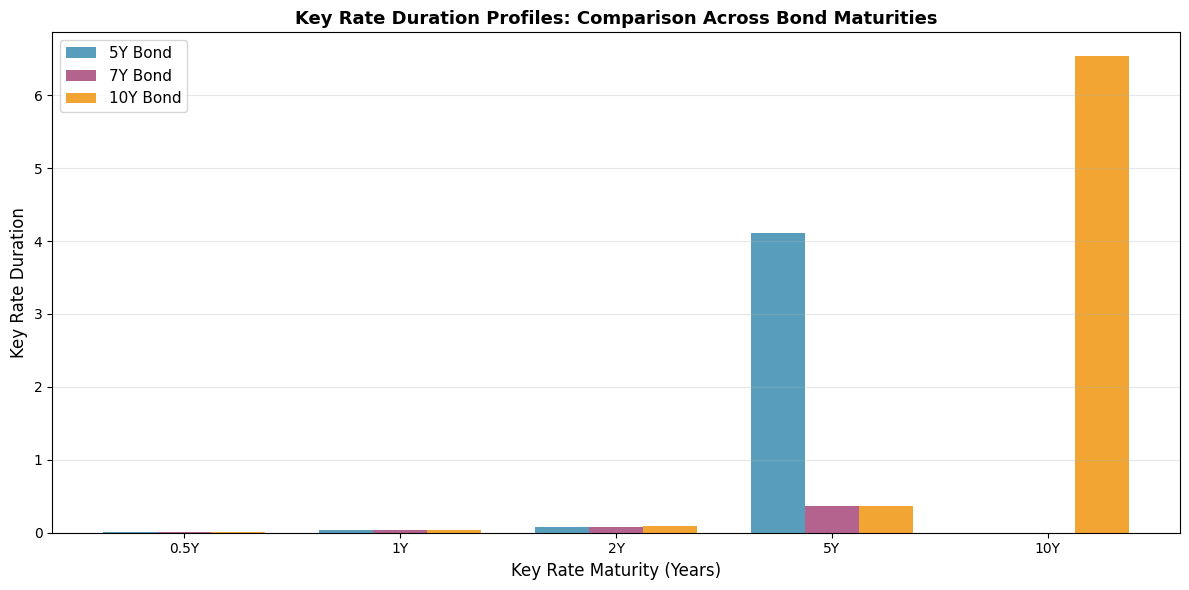

Observation: Each bond has maximum KRD sensitivity near its own maturity


In [11]:
# Visualize comparison of KRD profiles
fig, ax = plt.subplots(figsize=(12, 6))

# Get all unique key rate maturities
all_key_mats = sorted(set().union(*[set(krds.keys()) for krds in all_krds.values()]))
x_positions = np.arange(len(all_key_mats))
width = 0.25

# Plot bars for each bond maturity
colors = ['#2E86AB', '#A23B72', '#F18F01']
for i, (bond_mat, color) in enumerate(zip(bond_maturities, colors)):
    krd_vals = [all_krds[bond_mat].get(km, 0) for km in all_key_mats]
    offset = (i - 1) * width
    ax.bar(x_positions + offset, krd_vals, width=width, 
           label=f'{bond_mat}Y Bond', alpha=0.8, color=color)

ax.set_xlabel('Key Rate Maturity (Years)', fontsize=12)
ax.set_ylabel('Key Rate Duration', fontsize=12)
ax.set_title('Key Rate Duration Profiles: Comparison Across Bond Maturities', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x_positions)
ax.set_xticklabels([f'{m}Y' for m in all_key_mats])
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Observation: Each bond has maximum KRD sensitivity near its own maturity")


In [12]:
# Example: Calculate DV01 (Dollar Value of 1 basis point) for a portfolio position
portfolio_position = 1_000_000  # $1M position in 10-year bonds

print("Portfolio Risk Analysis")
print("=" * 70)
print(f"Position: ${portfolio_position:,.0f} in 10-year bonds")
print(f"Bond Price: ${bond_px:.4f} per $100 face value\n")

print("Key Rate DV01 (Dollar exposure to 1bp move at each maturity):")
print(f"{'Maturity':<12} {'KRD':<12} {'DV01 (per $100)':<18} {'DV01 (Position)':<18}")
print("-" * 70)

for maturity, krd in sorted(krds.items()):
    # DV01 = KRD × 0.0001 × Bond Price
    dv01_per_100 = krd * 0.0001 * bond_px
    dv01_position = dv01_per_100 * (portfolio_position / 100)
    print(f"{maturity:>5.1f} year   {krd:>10.4f}   ${dv01_per_100:>16.4f}   ${dv01_position:>16.2f}")

total_dv01 = sum([krd * 0.0001 * bond_px * (portfolio_position / 100) 
                   for krd in krds.values()])
print(f"\nTotal DV01: ${total_dv01:,.2f}")
print("\nInterpretation:")
print("- A 1bp parallel shift in the entire curve → P&L change of ~${:,.0f}".format(total_dv01))
print("- A 1bp shift only at the 10Y point → P&L change of ~${:,.0f}".format(
    krds[10] * 0.0001 * bond_px * (portfolio_position / 100)))


Portfolio Risk Analysis
Position: $1,000,000 in 10-year bonds
Bond Price: $98.0525 per $100 face value

Key Rate DV01 (Dollar exposure to 1bp move at each maturity):
Maturity     KRD          DV01 (per $100)    DV01 (Position)   
----------------------------------------------------------------------
  0.5 year       0.0111   $          0.0001   $            1.09
  1.0 year       0.0378   $          0.0004   $            3.70
  2.0 year       0.0829   $          0.0008   $            8.13
  5.0 year       0.3573   $          0.0035   $           35.04
 10.0 year       6.6639   $          0.0653   $          653.41

Total DV01: $701.37

Interpretation:
- A 1bp parallel shift in the entire curve → P&L change of ~$701
- A 1bp shift only at the 10Y point → P&L change of ~$653
